# Loading required libraries

In [46]:
library(ggplot2)
library(patchwork)
library(tidyverse)
library(ggpubr)
library(ggrepel)
library(ggbeeswarm)
library(ComplexHeatmap)
library(circlize)
library(survminer)
library(survival)
library(forcats)
library(ggsignif); 
library(patchwork)

## Figures and Files Setup

In [47]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_3"

## Color palettes

In [49]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2-like macrophages" = "#66A61E",
  "M1-like macrophages" = "#00557F",
  "M1/M2-like macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Abdomen" = "#505050" # darker
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

main_group_colors <- c(
  "Tumor"      = "#44AA99",   
  "Myeloid"    = "#7B8EC8",   
  "Lymphoid"   = "#C98A92",   
  "Non-immune" = "#B39DDB",   
  "NFC"        = "#B8B8B8"    
)
gvsm2_colors = c(
    "Granulocyte-dominant" = "#B85AA6",
    "M2 Macrophage-dominant" = "#66A61E"
)

## Loading required data

In [50]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Non-Lung")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1-like macrophages", "M2-like macrophages", "M1/M2-like macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (10): cell_type, cell_category, patient_ID, exp_name, patient_exp, tumor...
dbl  (7): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_mo...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [51]:
celltype_percentage_exp <- read.csv(paste0(data_dir, "/celltype_percentage_exp.csv")) %>%
   mutate(patient_exp = factor(patient_exp, levels = patient_exp_order),
          patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
   arrange(patient_exp, patient_ID, cell_category)

celltype_percentage_patient <- read.csv(paste0(data_dir, "/celltype_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category)

cellparent_percentage_patient <- read.csv(paste0(data_dir, "/cellparent_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order)) %>%
arrange(patient_ID, cell_category_parent)

cellgroup_percentage_patient <- read.csv(paste0(data_dir, "/cellgroup_percentage_patient.csv")) %>%
mutate(patient_ID = factor(patient_ID, levels = patient_ID_order),
    cell_category_simplified = factor(cell_category_simplified, levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")))

In [52]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Abdomen")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Abdomen"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

# A

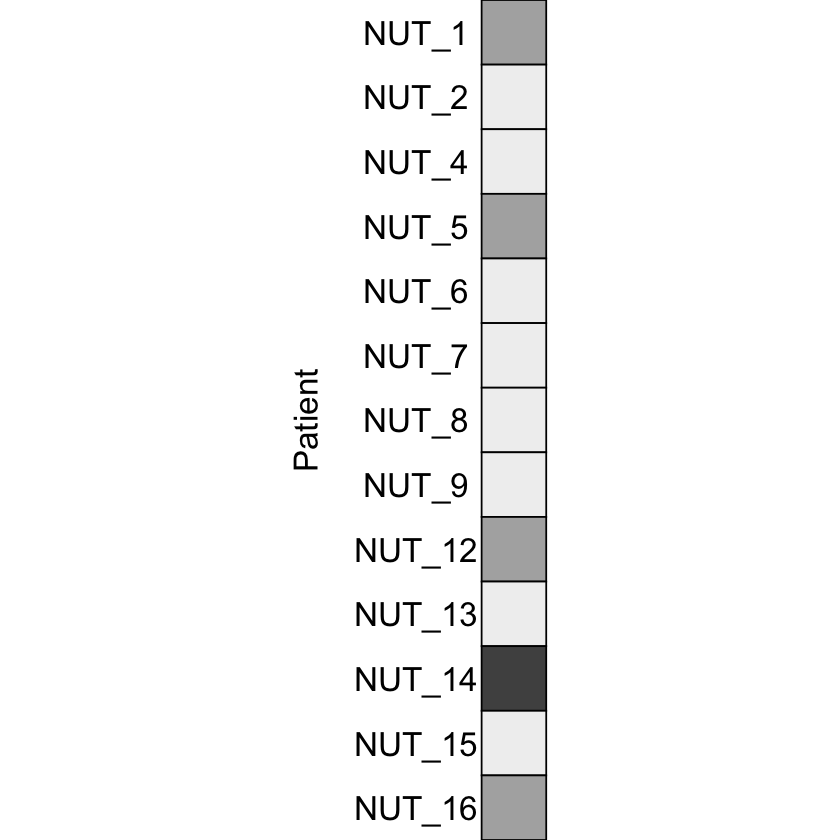

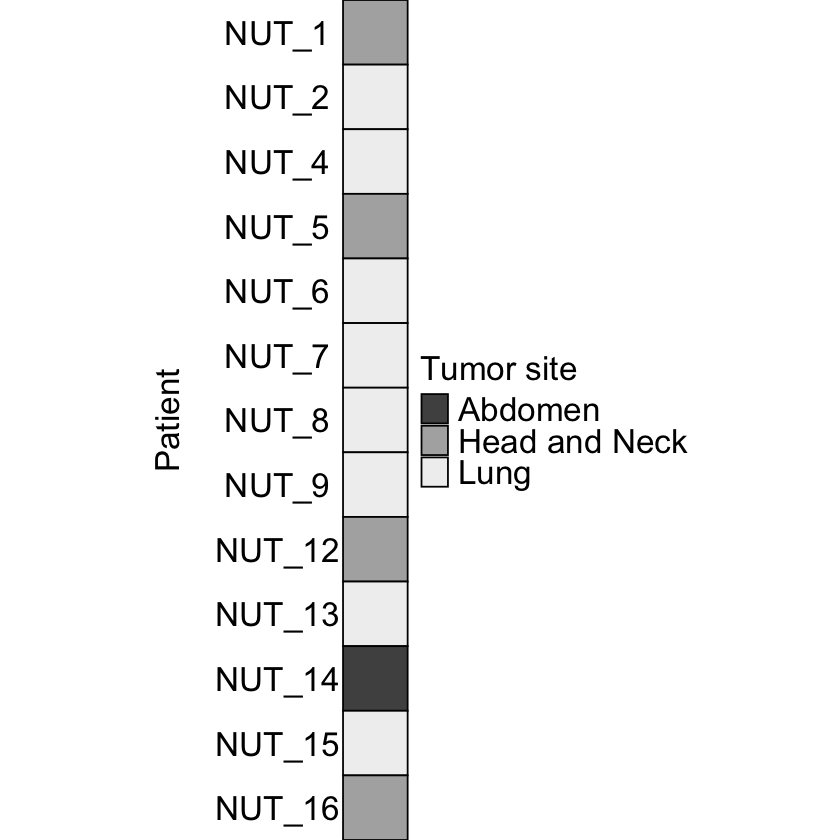

In [24]:
tumor_site_df <- celltype_metadata %>% 
    select(patient_ID, tumor_site) %>%
    distinct() 

tumor_site_plot <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
         legend.position = "none",
)
  tumor_site_plot

tumor_site_legend <- ggplot(tumor_site_df, aes(x = 1, y = patient_ID, fill = tumor_site)) +
  geom_tile(color = "black", size = 0.5) +  # black borders around squares
  scale_fill_manual(values = tumor_site_colors, name = "Tumor site") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  coord_fixed() +
  theme_void() +
  labs(y = "Patient") +
  theme(
     axis.text.y = element_text(size = 20, colour = "black"),
     axis.title.y = element_text(size = 20, colour = "black", angle = 90, margin = margin(r = 20)),
      legend.position = "right",
      legend.text = element_text(size = 20),
      legend.title = element_text(size = 20),
      legend.spacing.y = unit(3, "cm"))
tumor_site_legend
#extract the legend
tumor_site_legend_only <- get_legend(tumor_site_legend)
#save the legend
ggsave(
  filename = paste0(results_dir, "/tumor_site_legend.pdf"),
  plot = tumor_site_legend_only,
  width = 4,
  height = 4,
  dpi = 300
)

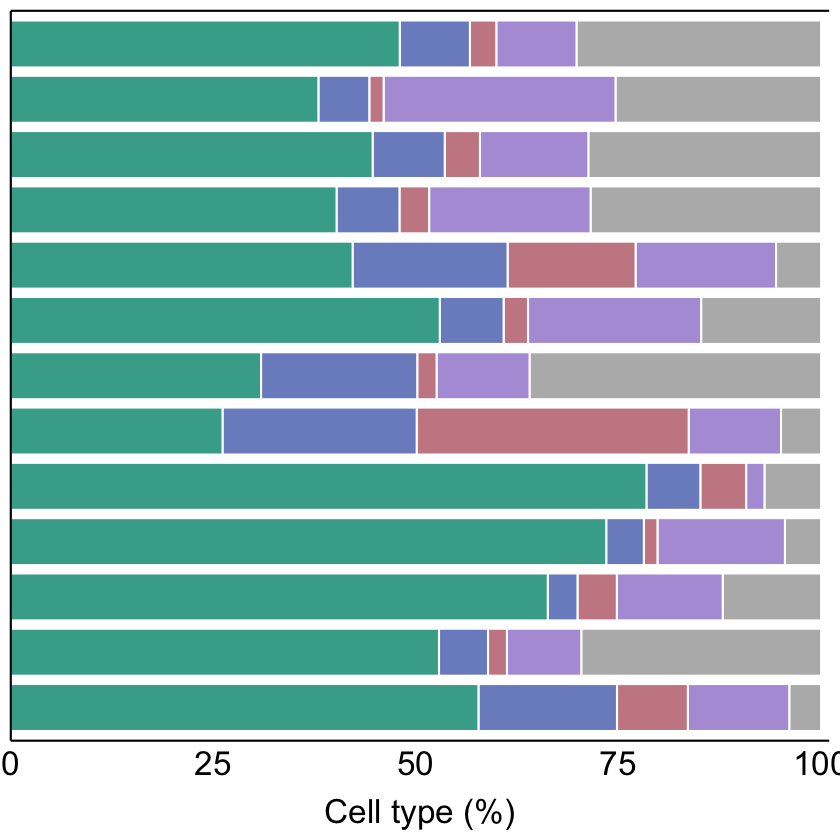

In [53]:
p_main = ggplot(
  cellgroup_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category_simplified)
) +
  geom_bar(stat = "identity", width = 0.85, colour = "white") +
  scale_fill_manual(values = main_group_colors) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Cell type (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_text(size = 20, colour = "black", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",
  )
p_main

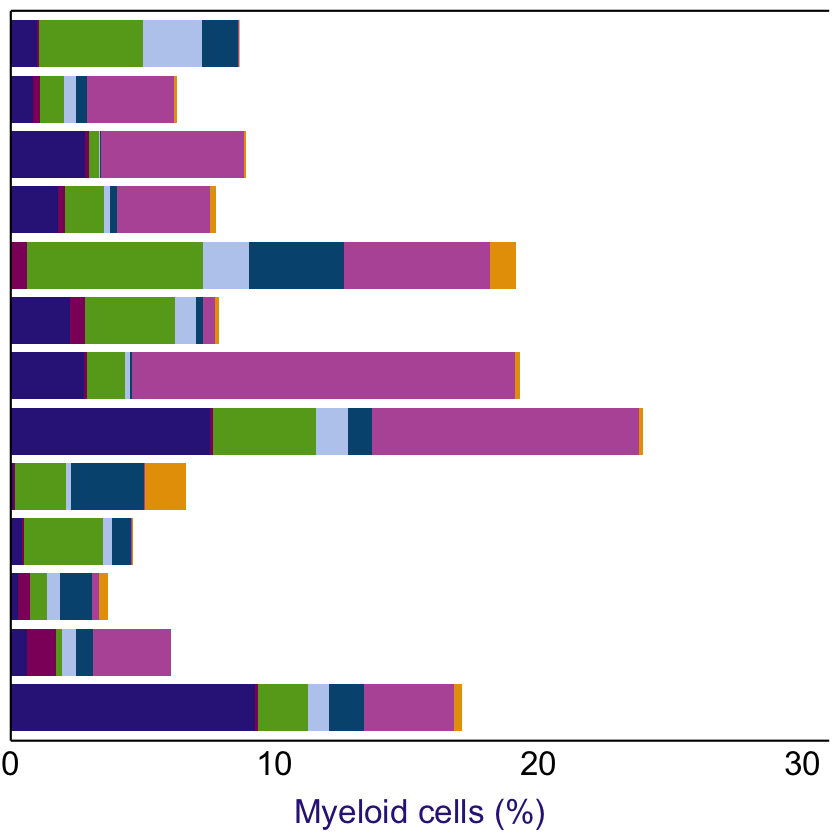

In [54]:
celltype_percentage_patient_myeloid <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Myeloid")

p_myeloid = ggplot(
  celltype_percentage_patient_myeloid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = myeloid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Myeloid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x  = element_text(size = 20, colour = "#332288", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    panel.grid = element_blank(),
    legend.position = "none",

  )
p_myeloid

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


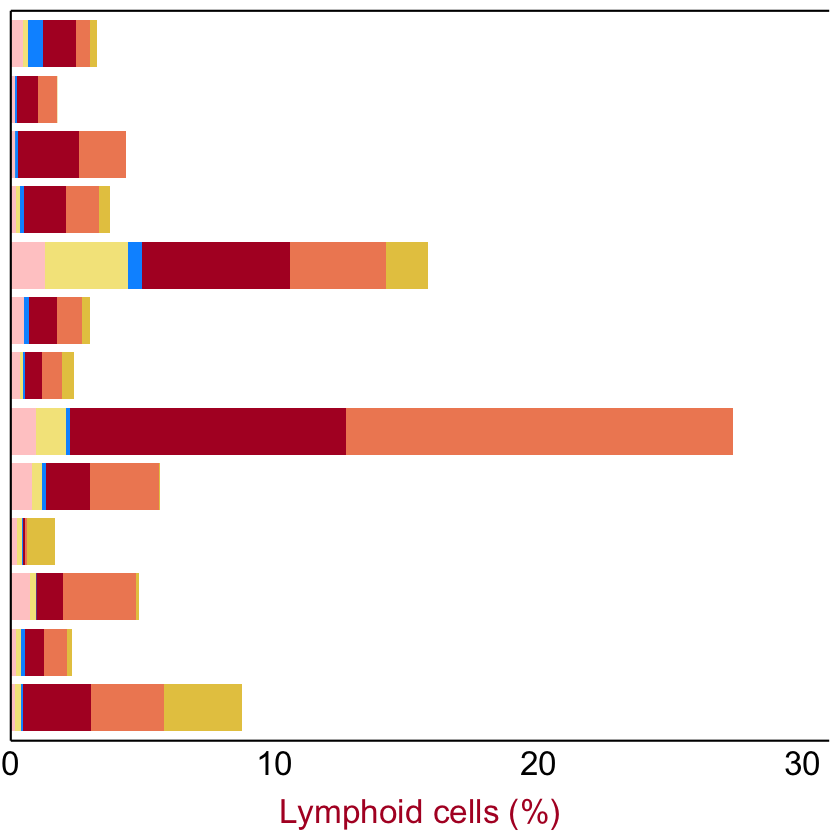

In [55]:
celltype_percentage_patient_lymphoid <- celltype_percentage_patient %>%
filter(cell_category_simplified == "Lymphoid")


p_lymphoid = ggplot(
  celltype_percentage_patient_lymphoid,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = lymphoid_palette) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Lymphoid cells (%)",
    y = "Patient",
    fill = "Cell type"
  ) +
  scale_x_continuous(limits = c(0, 31), expand = c(0, 0), sec.axis = dup_axis()) +
  scale_y_discrete(limits = rev) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_blank(),
    axis.title.y = element_blank(),
    axis.text.x = element_text(size = 20, colour = "black"),
    axis.title.x = element_text(size = 20, colour = "#B2182B", margin = margin(t = 10)),
    panel.border = element_blank(),
    axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
    axis.line.x.top    = element_line(colour="black", linewidth=0.6),
    axis.line.y.left   = element_line(colour="black", linewidth=0.6),
    axis.line.y.right  = element_blank(),
    axis.text.x.top  = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.title.x.top = element_blank(),
    axis.line = element_line(colour = "black", linewidth = 0.6),
    panel.grid = element_blank(),
    legend.position = "none",
  )
p_lymphoid

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


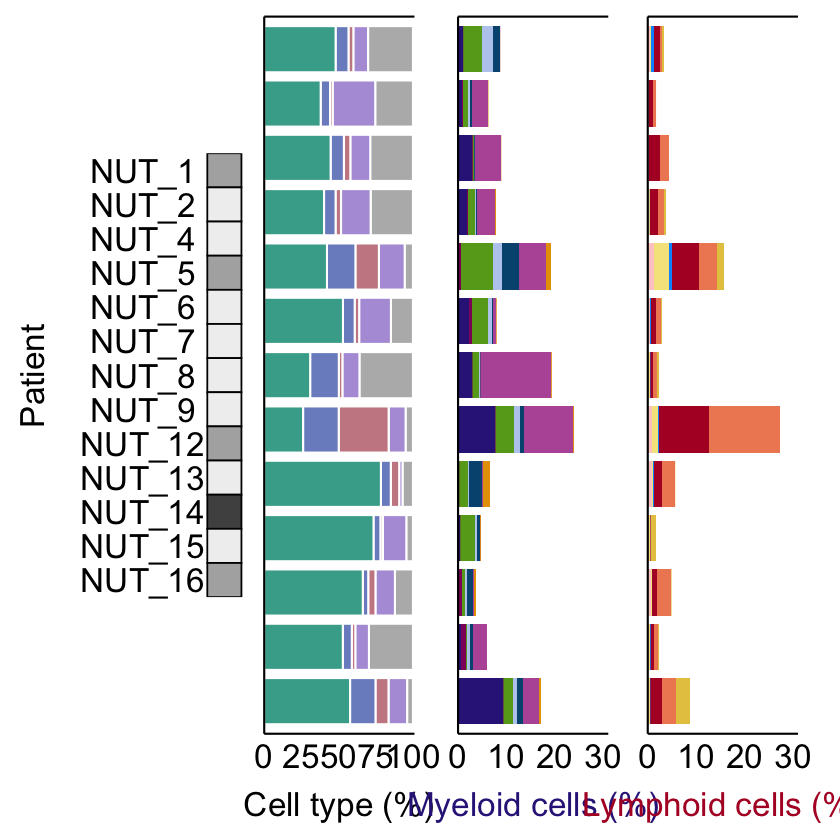

In [ ]:
final_plot <- wrap_plots(
  tumor_site_plot, plot_spacer(), p_main, plot_spacer(), p_myeloid, plot_spacer(), p_lymphoid,
  ncol = 9,
  widths = c(1,-0.5,4,0.1,4,-0.01,4)
) & theme(plot.margin = margin(t=5, r=7, b=5, l=5))
final_plot
ggsave(
  filename = paste0(results_dir, "/cellular_proportions_barplot.pdf"),
  plot = final_plot,
  width = 16,
  height = 6,
  dpi = 300
)


# B

Warning message in geom_beeswarm(width = 0.15, size = 2, alpha = 0.8, color = "black"):
“Ignoring unknown parameters: `width`”


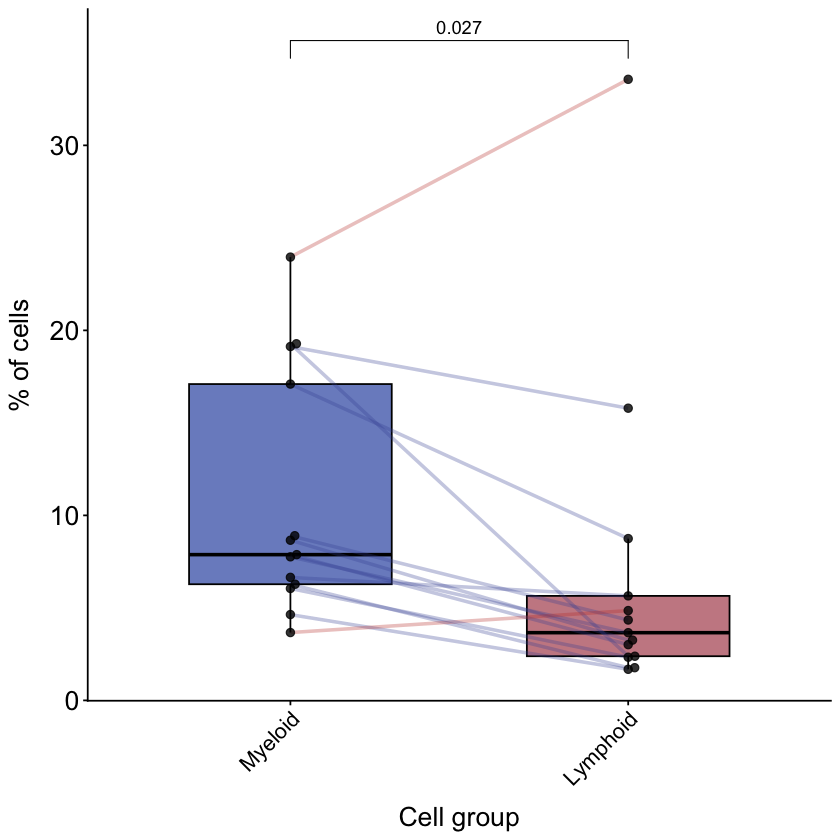

In [97]:
cellgroup_percentage_patient_mvsl <- cellgroup_percentage_patient %>%
  filter(cell_category_simplified %in% c("Myeloid", "Lymphoid")) %>%
  mutate(cell_category_simplified = factor(cell_category_simplified,
                                           levels = c("Myeloid", "Lymphoid")))

# --- compute dominance per patient: which is higher, myeloid or lymphoid? ---
dominance <- cellgroup_percentage_patient_mvsl %>%
  select(patient_ID, cell_category_simplified, percentage) %>%
  pivot_wider(names_from = cell_category_simplified, values_from = percentage) %>%
  mutate(lvsm = ifelse(Lymphoid > Myeloid, "Lymphoid-dominant", "Myeloid-dominant")) %>%
  select(patient_ID, lvsm)

cellgroup_percentage_patient_mvsl <- cellgroup_percentage_patient_mvsl %>%
  left_join(dominance, by = "patient_ID")

pd <- position_dodge(0.8)
line_cols <- c("Myeloid-dominant" = "#4053a3", "Lymphoid-dominant" = "#c0392b")

p <- ggplot(cellgroup_percentage_patient_mvsl,
            aes(x = cell_category_simplified, y = percentage)) +
  geom_boxplot(aes(fill = cell_category_simplified),
    position = pd, width = 0.6, alpha = 1, color = "black", outlier.shape = NA) +
  # one line per patient, coloured by which compartment dominates
  geom_line(aes(group = patient_ID, colour = lvsm), alpha = 0.3, linewidth = 1) +
  geom_beeswarm(width = 0.15, size = 2, alpha = 0.8, color = "black") +
  stat_compare_means(
    method = "wilcox.test", label = "p.format", paired = TRUE,
    label.y = max(cellgroup_percentage_patient_mvsl$percentage, na.rm = TRUE) + 0.5,
    label.x = 1.5,
    comparisons = list(c("Myeloid", "Lymphoid"))
  ) +
  scale_fill_manual(values = main_group_colors, guide = "none") +
  scale_colour_manual(values = line_cols, name = NULL) +
  labs(x = "Cell group", y = "% of cells") +
  theme_classic() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 45, hjust = 1, size = 13),
    axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  )
p

ggsave(filename = paste0(results_dir, "/myeloid_lymphoid_boxplot.pdf"),
       plot = p, width = 5, height = 5, dpi = 300, bg = "white")

# C

In [139]:
# #summarise the cell categories by their mean, sd, se.. we want to make error bars plot
# celltype_percentage_patient_myeloid_summary <- celltype_percentage_patient_myeloid %>%
# group_by(cell_category) %>%
# summarise(
#   mean_percentage = mean(percentage, na.rm = TRUE),
#   sd_percentage = sd(percentage, na.rm = TRUE),
#   se_percentage = sd_percentage / sqrt(n()),
#   .groups = "drop"
# )
# celltype_percentage_patient_myeloid_summary
#
# myeloid_errorbar_plot = ggplot(
#   celltype_percentage_patient_myeloid_summary,
#   aes(x = reorder(cell_category, -mean_percentage), 
#       y = mean_percentage, 
#       fill = cell_category)
# ) +
#   geom_bar(stat = "identity", width = 0.7, color = "black", linewidth = 0.4) +
#   geom_errorbar(
#     aes(ymin = mean_percentage - se_percentage, 
#         ymax = mean_percentage + se_percentage),
#     width = 0.25,
#     linewidth = 0.5,
#     color = "black"
#   ) +
#   labs(
#     x = "Myeloid cells",
#     y = "Mean percentage (%)",
#   ) +
#   scale_fill_manual(values = full_palette) +
#   theme_minimal(base_size = 14) +
#   theme(
#     axis.text.x = element_text(color = "black", size = 16, angle = 45, hjust = 1),
#     axis.text.y = element_text(color = "black", size = 16),
#     axis.title.x = element_text(color = "black", size = 16, margin = margin(t = 10)),
#     axis.title.y = element_text(color = "black", size = 16),
#     panel.grid.major.x = element_blank(),
#     panel.grid.minor = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, linewidth = 0.6),
#     legend.position = "none"
#   )

# myeloid_errorbar_plot
# #save the plot
# ggsave(
#   filename = paste0(results_dir, "/myeloid_errorbar_plot.pdf"),
#   plot = myeloid_errorbar_plot,
#   width = 5,
#   height = 5,
#   dpi = 300
# )

cell_category,mean_percentage,sd_percentage,se_percentage
<chr>,<dbl>,<dbl>,<dbl>
DCs,0.3399458,0.4635188,0.13380634
Granulocytes,3.8143506,4.3561515,1.20817905
M1-like macrophages,1.0458556,1.0633736,0.29492676
M1/M2-like macrophages,0.7099995,0.6589952,0.18277239
M2-like macrophages,2.2971838,1.8363235,0.50930450
MDSCs,2.4764938,2.9431115,0.84960311
Mast cells,0.2979044,0.3098402,0.08593421


In [ ]:
myeloid_cells  <- c("Granulocytes", "MDSCs", "M2-like macrophages", "M1-like macrophages",
                    "M1/M2-like macrophages","DCs","Mast cells")
                                  
# myeloid_cells  <- c("DCs", "Granulocytes","M1-like macrophages", "M1/M2-like macrophages",
#                     "M2-like macrophages","Mast cells", "MDSCs")

lymphoid_cells <- c("CD8+ T cells","CD4+ T cells","Treg T cells","B cells",
                    "NK cells","PCs")

# lymphoid_cells <- c("B cells", "CD4+ T cells","CD8+ T cells","NK cells", "PCs", "Treg T cells")

d <- celltype_percentage_patient %>%
   filter(cell_category %in% c(myeloid_cells, lymphoid_cells))

# ---- pairwise Wilcoxon: each myeloid vs each lymphoid ----
grid_res <- expand.grid(myeloid = myeloid_cells, lymphoid = lymphoid_cells,
                        stringsAsFactors = FALSE) %>%
  pmap_dfr(function(myeloid, lymphoid) {
    # pair by patient so each patient contributes both values
    w <- d %>%
      filter(cell_category %in% c(myeloid, lymphoid)) %>%
      select(patient_ID, cell_category, percentage) %>%
      pivot_wider(names_from = cell_category, values_from = percentage) %>%
      tidyr::drop_na(all_of(c(myeloid, lymphoid)))

    p <- if (nrow(w) >= 3)
      suppressWarnings(wilcox.test(w[[myeloid]], w[[lymphoid]],
                                   paired = TRUE, exact = FALSE)$p.value)
    else NA_real_

    tibble(myeloid, lymphoid,
           diff = median(w[[myeloid]] - w[[lymphoid]], na.rm = TRUE),  # median paired diff
           p = p)
  })

# ---- reshape to matrices: rows = myeloid, cols = lymphoid ----
diff_mat <- grid_res %>%
  select(myeloid, lymphoid, diff) %>%
  pivot_wider(names_from = lymphoid, values_from = diff) %>%
  tibble::column_to_rownames("myeloid") %>%
  as.matrix()
diff_mat <- diff_mat[myeloid_cells, lymphoid_cells]   # enforce order

star_mat <- grid_res %>%
  mutate(stars = ifelse(p < 0.0001, "***",
                 ifelse(p < 0.001,  "**",
                 ifelse(p < 0.05,   "*", "")))) %>%       # blank if not significant
  select(myeloid, lymphoid, stars) %>%
  pivot_wider(names_from = lymphoid, values_from = stars) %>%
  tibble::column_to_rownames("myeloid") %>%
  as.matrix()
star_mat <- star_mat[myeloid_cells, lymphoid_cells]

# ---- color: diverging around 0 (blue = lymphoid higher, red = myeloid higher) ----
lim <- max(abs(diff_mat), na.rm = TRUE)
col_fun <- colorRamp2(c(-lim, 0, lim), c("#2166AC", "white", "#B2182B"))

ht <- Heatmap(
  diff_mat,
  name = "median_diff",
  col = col_fun,
  cluster_rows = FALSE, cluster_columns = FALSE,
  rect_gp = gpar(col = "white", lwd = 2),
  row_names_side = "left", column_names_side = "bottom",
  column_names_rot = 45,
  row_names_gp = gpar(fontsize = 12),
  column_names_gp = gpar(fontsize = 12),
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(star_mat[i, j], x, y,
              gp = gpar(fontsize = 14))
  },
  heatmap_legend_param = list(
    title = "Difference in median percentage\n(Myeloid − Lymphoid, %)",
    title_gp = gpar(fontsize = 10),
    labels_gp = gpar(fontsize = 10)
  ),
  column_title = "Myeloid vs Lymphoid abundance",
  column_title_gp = gpar(fontsize = 13)
)

draw(ht)

# ---- save ----
cairo_pdf(file.path(results_dir, "myeloid_vs_lymphoid_heatmap.pdf"),
          width = 7.5, height = 4)

draw(ht)
dev.off()

# D-E

In [43]:
three_group_abund_plot <- function(df, types, x_label, alpha = 0.05) {
  d <- df %>%
    filter(cell_category %in% types) %>%
    mutate(cell = factor(cell_category, levels = types))

  # complete pairs only (drops patients missing a group, needed for paired test)
  complete_ids <- d %>% distinct(patient_ID, cell_category) %>%
    count(patient_ID) %>% filter(n == length(types)) %>% pull(patient_ID)
  d <- d %>% filter(patient_ID %in% complete_ids)

  # pairwise paired Wilcoxon -> keep only significant
  wide <- d %>% select(patient_ID, cell, percentage) %>%
    pivot_wider(names_from = cell, values_from = percentage)

  sig <- combn(types, 2, simplify = FALSE) %>%
    map_dfr(function(pr) {
      p <- suppressWarnings(wilcox.test(wide[[pr[1]]], wide[[pr[2]]],
                                        paired = TRUE, exact = FALSE)$p.value)
      tibble(g1 = pr[1], g2 = pr[2], p = p)
    }) %>%
    filter(!is.na(p), p < alpha) %>%
    arrange(p)

  y_max <- max(d$percentage, na.rm = TRUE)
  if (nrow(sig) > 0) {
    step <- y_max * 0.12
    sig <- sig %>% mutate(y = y_max * 1.05 + step * (row_number() - 1))
  }

  p <- ggplot(d, aes(x = cell, y = percentage, fill = cell)) +
    geom_boxplot(width = 0.6, alpha = 1, color = "black", outlier.shape = NA) +
    # geom_line(aes(group = patient_ID), colour = "grey70", alpha = 0.35, linewidth = 0.7) +
    geom_beeswarm(size = 2, alpha = 0.8, color = "black") +
    scale_fill_manual(values = full_palette, guide = "none") +
    labs(x = x_label, y = "% of all cells") +
    theme_classic(base_family = "Arial") +
    theme(legend.position = "none",
          axis.text.x = element_text(angle = 45, hjust = 1, size = 15),
          axis.title.x = element_text(size = 16, colour = "black", margin = margin(t = 8)),
          axis.text.y = element_text(size = 15, colour = "black"),
          axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 8)),
          axis.line = element_line(linewidth = 0.5, colour = "black"),
          axis.ticks = element_line(linewidth = 0.5, colour = "black"))

  if (nrow(sig) > 0) {
    p <- p + geom_signif(
      comparisons = Map(c, sig$g1, sig$g2),
      annotations = signif(sig$p, 2),
      y_position  = sig$y,
      tip_length  = 0.01, textsize = 3.4, family = "Arial") +
      scale_y_continuous(expand = expansion(mult = c(0.02, 0.05)),
                         limits = c(0, max(sig$y) * 1.06))
  } else {
    p <- p + scale_y_continuous(expand = expansion(mult = c(0.02, 0.15)))
  }
  p
}

p_macro <- three_group_abund_plot(
  celltype_percentage_patient_myeloid,
  c("M1-like macrophages","M1/M2-like macrophages","M2-like macrophages"),
  "Macrophage subtype")

p_tcell <- three_group_abund_plot(
  celltype_percentage_patient,
  c("CD4+ T cells","CD8+ T cells","Treg T cells"),
  "T cell subtype")

ggsave(paste0(results_dir, "/macro__abundance_combined.pdf"),
       p_macro, width = 5, height = 5, dpi = 300, bg = "white", device = cairo_pdf)

ggsave(paste0(results_dir, "/tcell_abundance_combined.pdf"),
       p_tcell, width = 5, height = 5, dpi = 300, bg = "white", device = cairo_pdf)
  

# Extra

patients with all 7 types: 11 
10 significant pairs of 21 tested
# A tibble: 10 × 3
   g1                     g2                           p
   <chr>                  <chr>                    <dbl>
 1 M2-like macrophages    M1/M2-like macrophages 0.00386
 2 M2-like macrophages    DCs                    0.00386
 3 M2-like macrophages    Mast cells             0.00386
 4 MDSCs                  Mast cells             0.00669
 5 M1-like macrophages    DCs                    0.0113 
 6 MDSCs                  DCs                    0.0185 
 7 M1/M2-like macrophages Mast cells             0.0185 
 8 M2-like macrophages    M1-like macrophages    0.0367 
 9 MDSCs                  M1/M2-like macrophages 0.0367 
10 Granulocytes           DCs                    0.0454 


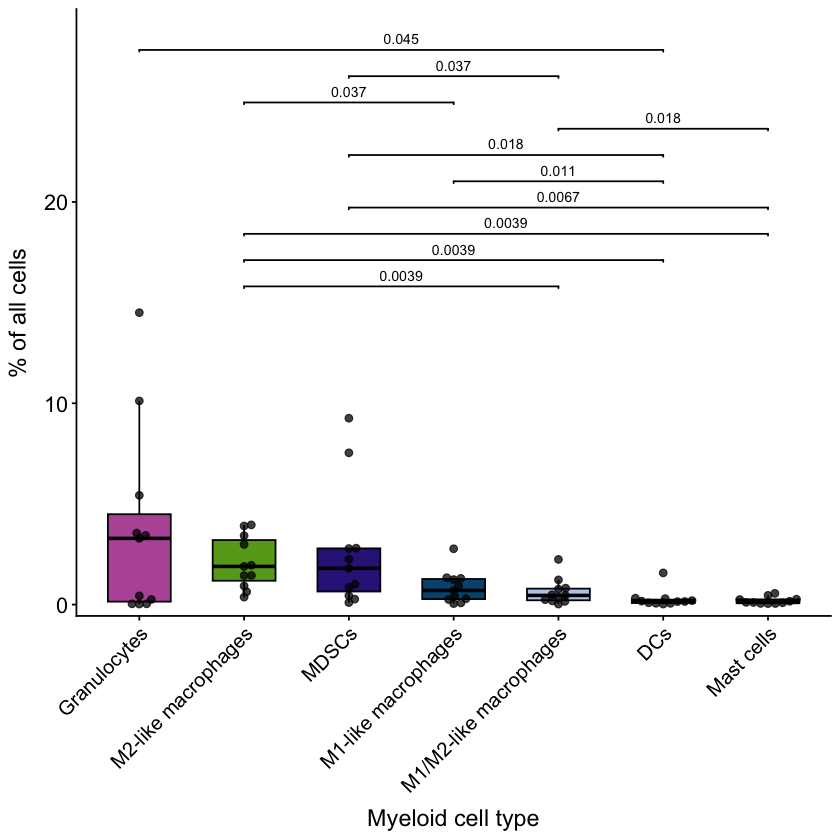

In [31]:
all_myeloid_plot <- function(df, types, x_label = "Myeloid cell type", alpha = 0.05) {

  d <- df %>% filter(cell_category %in% types)

  # complete cases: patients present in ALL groups (needed for paired tests)
  complete_ids <- d %>% distinct(patient_ID, cell_category) %>%
    count(patient_ID) %>% filter(n == length(types)) %>% pull(patient_ID)
  d <- d %>% filter(patient_ID %in% complete_ids)
  cat("patients with all", length(types), "types:", length(complete_ids), "\n")

  # order by MEDIAN abundance, descending
  ord <- d %>% group_by(cell_category) %>%
    summarise(m = median(percentage, na.rm = TRUE), .groups = "drop") %>%
    arrange(desc(m)) %>% pull(cell_category)
  d <- d %>% mutate(cell = factor(cell_category, levels = ord))

  # all pairwise paired Wilcoxon -> keep only significant
  wide <- d %>% select(patient_ID, cell, percentage) %>%
    pivot_wider(names_from = cell, values_from = percentage)

  sig <- combn(ord, 2, simplify = FALSE) %>%
    map_dfr(function(pr) {
      p <- suppressWarnings(wilcox.test(wide[[pr[1]]], wide[[pr[2]]],
                                        paired = TRUE, exact = FALSE)$p.value)
      tibble(g1 = pr[1], g2 = pr[2], p = p)
    }) %>%
    filter(!is.na(p), p < alpha) %>%
    arrange(p)

  cat(nrow(sig), "significant pairs of", choose(length(types), 2), "tested\n")
  print(sig)

  y_max <- max(d$percentage, na.rm = TRUE)
  if (nrow(sig) > 0) {
    step <- y_max * 0.09
    sig <- sig %>% mutate(y = y_max * 1.04 + step * (row_number() - 1))
  }

  p <- ggplot(d, aes(x = cell, y = percentage, fill = cell)) +
    geom_boxplot(width = 0.6, alpha = 1, color = "black", outlier.shape = NA) +
    geom_beeswarm(size = 1.8, alpha = 0.75, color = "black") +
    scale_fill_manual(values = full_palette, guide = "none") +
    labs(x = x_label, y = "% of all cells") +
    theme_classic(base_family = "Arial") +
    theme(legend.position = "none",
          axis.text.x = element_text(angle = 45, hjust = 1, size = 12, colour = "black"),
          axis.title.x = element_text(size = 14, colour = "black", margin = margin(t = 8)),
          axis.text.y = element_text(size = 13, colour = "black"),
          axis.title.y = element_text(size = 14, colour = "black", margin = margin(r = 8)),
          axis.line = element_line(linewidth = 0.5, colour = "black"),
          axis.ticks = element_line(linewidth = 0.5, colour = "black"))

  if (nrow(sig) > 0) {
    p <- p + geom_signif(
      comparisons = Map(c, sig$g1, sig$g2),
      annotations = signif(sig$p, 2),
      y_position  = sig$y,
      tip_length  = 0.006, textsize = 3, family = "Arial") +
      scale_y_continuous(expand = expansion(mult = c(0.02, 0.05)),
                         limits = c(0, max(sig$y) * 1.05))
  } else {
    p <- p + scale_y_continuous(expand = expansion(mult = c(0.02, 0.15)))
  }
  p
}

p_myeloid <- all_myeloid_plot(celltype_percentage_patient_myeloid, myeloid)
p_myeloid

ggsave(paste0(results_dir, "/all_myeloid_abundance_boxplot.pdf"),
       p_myeloid, width = 8, height = 7, dpi = 300, bg = "white", device = cairo_pdf)

patients with all 6 types: 10 
8 significant pairs of 15 tested
# A tibble: 8 × 3
  g1           g2                 p
  <chr>        <chr>          <dbl>
1 CD8+ T cells NK cells     0.00592
2 CD4+ T cells PCs          0.00805
3 CD4+ T cells NK cells     0.00805
4 CD8+ T cells Treg T cells 0.00805
5 CD8+ T cells PCs          0.00805
6 CD4+ T cells Treg T cells 0.0108 
7 Treg T cells NK cells     0.0191 
8 CD4+ T cells B cells      0.0415 


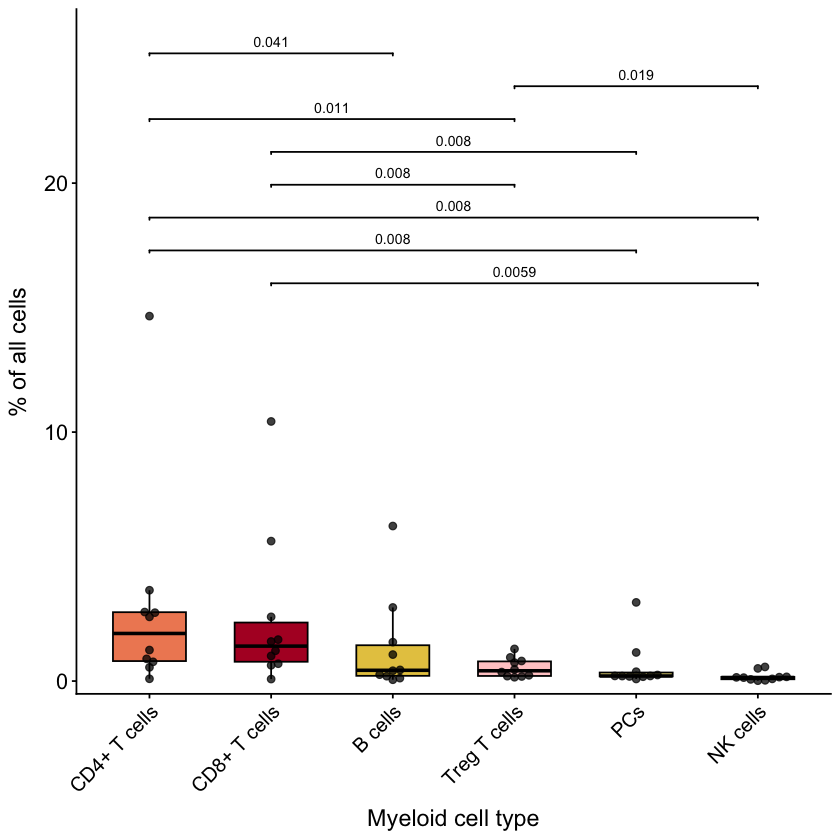

In [45]:
p_lymphoid <- all_myeloid_plot(celltype_percentage_patient_lymphoid, lymphoid)
p_lymphoid

ggsave(paste0(results_dir, "/all_lymphoid_abundance_boxplot.pdf"),
       p_lymphoid, width = 8, height = 7, dpi = 300, bg = "white", device = cairo_pdf)

# D

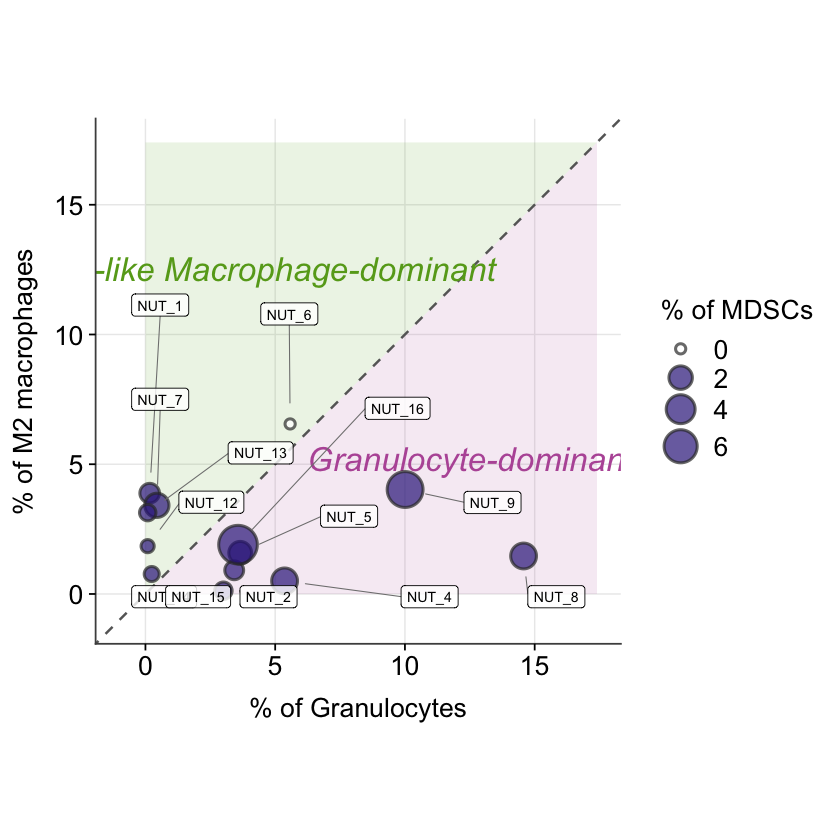

In [168]:
scatter_df <- celltype_percentage_patient_myeloid %>%
  filter(cell_category %in% c("Granulocytes", "M2-like macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2-like macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

ax_max <- max(scatter_df$granulocytes, scatter_df$m2_macro) * 1.2

ggplot(scatter_df, aes(x = granulocytes, y = m2_macro)) +

  # shaded triangles
  annotate("polygon",
           x = c(0, ax_max, ax_max),
           y = c(0, 0,      ax_max),
           fill = full_palette["Granulocytes"], alpha = 0.12) +
  annotate("polygon",
           x = c(0, 0,      ax_max),
           y = c(0, ax_max, ax_max),
           fill = full_palette["M2-like macrophages"], alpha = 0.12) +

  # diagonal
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey40", linewidth = 0.7) +

  # region labels
  annotate("text",
           x = ax_max * 0.72, y = ax_max * 0.30,
           label = "Granulocyte-dominant",
           color = full_palette["Granulocytes"],
           size = 7, fontface = "italic") +
  annotate("text",
           x = ax_max * 0.28, y = ax_max * 0.72,
           label = "M2-like Macrophage-dominant",
           color = full_palette["M2-like macrophages"],
           size = 7, fontface = "italic") +

  # points
  geom_point(aes(size = mdscs,
                 fill = ifelse(mdscs == 0, "white", full_palette["MDSCs"])),
             shape    = 21,
             color    = "grey20",
             alpha    = 0.7,
             stroke   = 1.3,
             position = position_jitter(width = 0.15, height = 0.15, seed = 42)) +

  scale_fill_identity() +
  scale_size_continuous(
    name   = "% of MDSCs",
    range  = c(2, 10),
    breaks = c(0, 2, 4, 6)
  ) +

  guides(
    size = guide_legend(
      override.aes = list(
        fill  = c("white", full_palette["MDSCs"], full_palette["MDSCs"], full_palette["MDSCs"]),
        color = "grey20"
      )
    ),
    fill = "none"
  ) +

  # single geom_label_repel — no xlim/ylim constraints, just maximum repulsion
  geom_label_repel(
    aes(label = patient_ID),
    size               = 3,
    fill               = alpha("white", 0.80),
    label.size         = 0.2,
    box.padding        = 1.5,
    point.padding      = 0.8,
    max.overlaps       = Inf,
    force              = 15,
    force_pull         = 0.1,
    min.segment.length = 0,
    segment.color      = "grey50",
    segment.size       = 0.3,
    seed               = 42,
    position           = position_jitter(width = 0.15, height = 0.15, seed = 42)
  ) +

  coord_fixed(ratio = 1,
              xlim  = c(-1, ax_max),
              ylim  = c(-1, ax_max)) +

  labs(
    x = "% of Granulocytes",
    y = "% of M2 macrophages"
  ) +

  theme_classic(base_size = 16) +
  theme(
    legend.position  = "right",
    legend.title     = element_text(size = 16),
    legend.text      = element_text(size = 16),
    axis.text.x      = element_text(size = 16, colour = "black"),
    axis.title.x     = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/granulocyte_m2_macro_scatter.pdf"),
       width = 10, height = 8, dpi = 300, bg = "white")

In [ ]:
scatter_df <- celltype_percentage_patient_myeloid %>%
  filter(cell_category %in% c("Granulocytes", "M2 macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2 macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

ax_max <- max(scatter_df$granulocytes, scatter_df$m2_macro) * 1.2

ggplot(scatter_df, aes(x = granulocytes, y = m2_macro)) +

  # shaded triangles
  annotate("polygon",
           x = c(0, ax_max, ax_max),
           y = c(0, 0,      ax_max),
           fill = full_palette["Granulocytes"], alpha = 0.12) +
  annotate("polygon",
           x = c(0, 0,      ax_max),
           y = c(0, ax_max, ax_max),
           fill = full_palette["M2 macrophages"], alpha = 0.12) +

  # diagonal
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey40", linewidth = 0.7) +

  # region labels
  annotate("text",
           x = ax_max * 0.72, y = ax_max * 0.30,
           label = "Granulocyte-dominant",
           color = full_palette["Granulocytes"],
           size = 7, fontface = "italic") +
  annotate("text",
           x = ax_max * 0.28, y = ax_max * 0.72,
           label = "M2 Macrophage-dominant",
           color = full_palette["M2 macrophages"],
           size = 7, fontface = "italic") +

  # points
  geom_point(aes(size = mdscs,
                 fill = ifelse(mdscs == 0, "white", full_palette["MDSCs"])),
             shape    = 21,
             color    = "grey20",
             alpha    = 0.7,
             stroke   = 1.3,
             position = position_jitter(width = 0.15, height = 0.15, seed = 42)) +

  scale_fill_identity() +
  scale_size_continuous(
    name   = "% of MDSCs",
    range  = c(2, 10),
    breaks = c(0, 2, 4, 6)
  ) +

  guides(
    size = guide_legend(
      override.aes = list(
        fill  = c("white", full_palette["MDSCs"], full_palette["MDSCs"], full_palette["MDSCs"]),
        color = "grey20"
      )
    ),
    fill = "none"
  ) +

  # single geom_label_repel — no xlim/ylim constraints, just maximum repulsion
  geom_label_repel(
    aes(label = patient_ID),
    size               = 3,
    fill               = alpha("white", 0.80),
    label.size         = 0.2,
    box.padding        = 1.5,
    point.padding      = 0.8,
    max.overlaps       = Inf,
    force              = 15,
    force_pull         = 0.1,
    min.segment.length = 0,
    segment.color      = "grey50",
    segment.size       = 0.3,
    seed               = 42,
    position           = position_jitter(width = 0.15, height = 0.15, seed = 42)
  ) +

  coord_fixed(ratio = 1,
              xlim  = c(-1, ax_max),
              ylim  = c(-1, ax_max)) +

  labs(
    x = "% of Granulocytes",
    y = "% of M2 macrophages"
  ) +

  theme_classic(base_size = 16) +
  theme(
    legend.position  = "right",
    legend.title     = element_text(size = 16),
    legend.text      = element_text(size = 16),
    axis.text.x      = element_text(size = 16, colour = "black"),
    axis.title.x     = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/granulocyte_m2_macro_scatter.pdf"),
       width = 10, height = 8, dpi = 300, bg = "white")

In [86]:
celltype_percentage_patient_survival <- celltype_percentage_patient %>%
  left_join(
    survival_df,
    by = "patient_ID"
  ) %>%
  arrange(tumor_site, survival_time_months)

celltype_percentage_patient_survival_myeloid <- celltype_percentage_patient_survival %>%
filter(cell_category_simplified == "Myeloid")

celltype_percentage_patient_survival_myeloid_ht <- celltype_percentage_patient_survival_myeloid %>%
    select(patient_ID, cell_category, clr) %>%
    pivot_wider(names_from = patient_ID, values_from = clr) %>%
    column_to_rownames(var = "cell_category") %>%
    as.matrix()
col_split <- survival_df %>%
  arrange(tumor_site, survival_time_months) %>%
  pull(tumor_site) 
  #remove the factor
celltype_percentage_patient_survival_myeloid_ht

,NUT_9,NUT_2,NUT_4,NUT_8,NUT_15,NUT_13,NUT_6,NUT_7,NUT_5,NUT_16,NUT_12,NUT_1,NUT_14
DCs,-2.5732919,-2.39040616,-2.3365387,-1.7186793,NA,-2.55709437,-1.1408795,-2.0182651,-2.0411021,-1.2301154,0.9029646,-3.4733861,-1.1700732
Granulocytes,1.4945112,1.19588671,2.1370031,2.7143499,1.06970373,-2.84700362,0.5966880,-1.3322760,1.1589058,0.9154100,-2.8448574,-3.3618143,-1.2557938
M1 macrophages,-0.7883473,-0.88632876,-2.5596822,-2.4353570,-0.49549400,0.34523209,0.1693625,-1.7126195,-1.8566552,0.1011700,1.4688139,0.4686668,0.3538327
M1/M2 macrophages,-0.5091398,-0.78096824,-3.2528294,-1.6512380,-0.65466712,-0.25291183,-0.5655154,-0.6754385,-1.5229456,-0.3895413,-1.3895701,1.0057955,-0.5608118
M2 macrophages,0.6652293,-0.07293245,-0.5447792,0.4089985,-1.48610226,1.95225337,0.7831479,1.0479240,0.2374356,0.3478107,1.1173154,1.5040012,-0.3575842
MDSCs,1.3201017,-0.14969647,1.4760323,1.0640324,-0.87987197,0.02128253,NA,0.6499086,0.4372894,2.1879135,-1.8463285,0.1066485,-1.1539725
Mast cells,-3.5871129,-1.37880524,-1.3557094,-2.2217829,0.07100177,-2.11936000,-1.6035031,-0.9386838,-1.4274725,-2.6063084,-2.4881824,-2.8470046,-0.6249139


# D

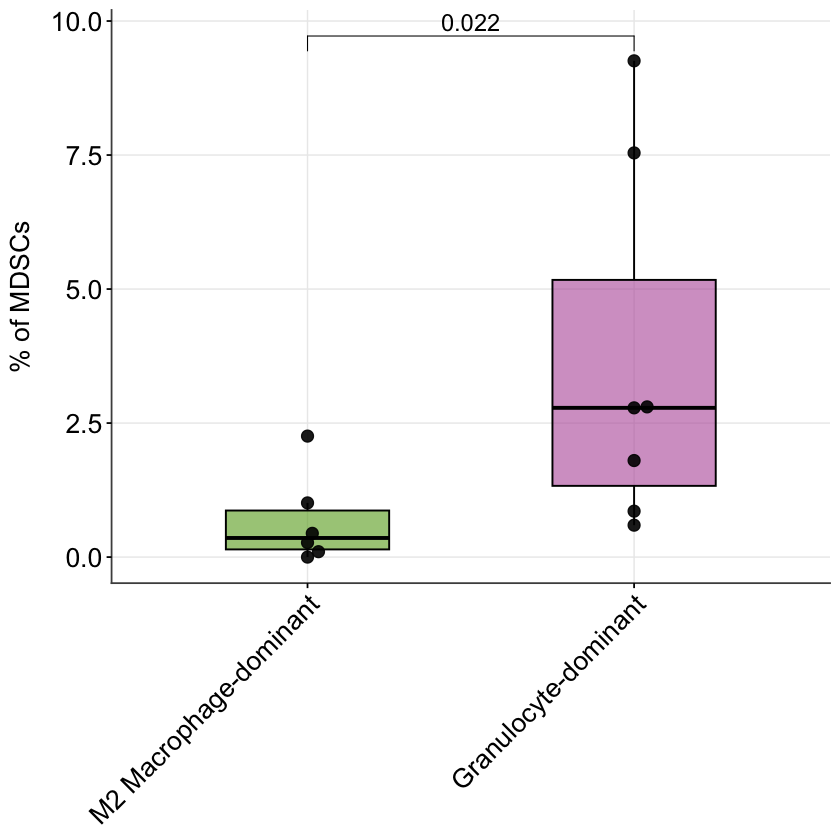

In [143]:
 scatter_df <- celltype_percentage_patient_myeloid %>%
  filter(cell_category %in% c("Granulocytes", "M2 macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2 macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

# Classify patients
mdsc_compare_df <- scatter_df %>%
  select(patient_ID, granulocytes, m2_macro, mdscs, dominant) %>%
  mutate(
    dominant_label = ifelse(dominant == "gran",
                            "Granulocyte-dominant",
                            "M2 Macrophage-dominant")
  ) %>%
  mutate(dominant_label = factor(dominant_label, levels = c("M2 Macrophage-dominant", "Granulocyte-dominant")))

comparisons <- list(c("M2 Macrophage-dominant", "Granulocyte-dominant"))

ggplot(mdsc_compare_df, aes(x = dominant_label, y = mdscs, fill = dominant_label)) +

  geom_boxplot(
    width         = 0.5,
    alpha         = 0.6,
    color         = "black",
    outlier.shape = NA
  ) +

  geom_beeswarm(
    size  = 3,
    alpha = 0.9,
    color = "black",
    cex   = 2
  ) +

  stat_compare_means(
    comparisons = comparisons,
    method      = "wilcox.test",
    label       = "p.format",
    paired      = FALSE,
    size        = 5
  ) +

  scale_fill_manual(values = gvsm2_colors) +
  
  labs(
    x = NULL,
    y = "% of MDSCs"
  ) +

  theme_classic(base_size = 12) +
  theme(
    legend.position  = "none",
    axis.text.x      = element_text(size = 16, colour = "black", angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/mdsc_gran_vs_m2_boxplot.pdf"),
       width = 6, height = 6, dpi = 300, bg = "white")

# E

In [25]:
cell_types <- c("Granulocytes", "MDSCs", "M2 macrophages")

cor_results <- map_dfr(cell_types, function(ct) {
  ct_df <- celltype_percentage_patient %>%
    filter(cell_category == ct) %>%
    select(patient_ID, percentage) %>%
    left_join(survival_df, by = "patient_ID") %>%
    drop_na(percentage, survival_time_months)

  test <- cor.test(ct_df$percentage, ct_df$survival_time_months, method = "spearman")

  tibble(
    cell_type = ct,
    rho       = round(test$estimate, 2),
    p_val     = test$p.value
  )
}) %>%
  mutate(
    significant = p_val < 0.05,
    p_label     = ifelse(
      significant,
      paste0("p = ", round(p_val, 3), " *"),
      paste0("p = ", round(p_val, 3))
    ),
    cell_type = fct_reorder(cell_type, rho)
  )

ggplot(cor_results, aes(x = rho, y = cell_type)) +

  geom_vline(xintercept = 0, linetype = "dashed",
             color = "grey50", linewidth = 0.6) +

  geom_col(aes(fill = rho), width = 0.45,
           color = "grey20", linewidth = 0.3) +

  geom_text(
    aes(
      label    = p_label,
      x        = ifelse(rho < 0, rho - 0.03, rho + 0.03),
      hjust    = ifelse(rho < 0, 1, 0),
      fontface = ifelse(significant, "bold", "plain")
    ),
    size = 5.5, color = "black"
  ) +

scale_fill_gradientn(
    colors = c("#C1392B", "#FFFFFF", "#2471A3"),
    limits = c(-1, 1),
    name   = "Spearman rho"
  ) +

  scale_x_continuous(
    limits = c(-1.3, 0.9),
    breaks = seq(-1, 0.8, by = 0.2)
  ) +

  labs(
    x = "Correlation of cell percentage with survival time",
    y = NULL
  ) +

  theme_classic(base_size = 16) +
  theme(
    legend.position    = "right",
    legend.title       = element_text(size = 16),
    legend.text        = element_text(size = 14),
    axis.text.y        = element_text(size = 16, colour = "black"),
    axis.text.x        = element_text(size = 16, colour = "black"),
    axis.title.x       = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.line          = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks         = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major.x = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/survival_correlation_myeloid.pdf"),
       width = 10, height = 3, dpi = 300, bg = "white")

Warning message in cor.test.default(ct_df$percentage, ct_df$survival_time_months, :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(ct_df$percentage, ct_df$survival_time_months, :
“Cannot compute exact p-value with ties”


ERROR: [1m[33mError[39m in `map()`:[22m
[1m[22m[36mℹ[39m In index: 3.
[1mCaused by error in `cor.test.default()`:[22m
[33m![39m not enough finite observations


# F

In [267]:
celltype_percentage_patient_survival_gvsm2 <- celltype_percentage_patient %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  mutate(
    ratio = Granulocytes / `M2 macrophages` 
  ) %>%
  left_join(
    survival_df %>% select(patient_ID, is_lung, 
                           tumor_site, survival_time_months, event),
    by = "patient_ID"
  ) %>%
  mutate(ratio_group = ifelse(ratio < 1, "M2 Macrophages-dominant", "Granulocytes-dominant"),
  ratio_group = factor(ratio_group, levels = c("M2 Macrophages-dominant", "Granulocytes-dominant")))

# #perform a survival analysis using the percentage group as the variable of interest
fit <- survfit(Surv(survival_time_months, event) ~ ratio_group, data = celltype_percentage_patient_survival_gvsm2)
# Plot
surv_plot <- ggsurvplot(
fit,
data = celltype_percentage_patient_survival_gvsm2,
pval = TRUE,
conf.int = TRUE,
risk.table = TRUE,
risk.table.height = 0.25,
pval.coord = c(17, 0.7),
xlim = c(0, 20),
break.time.by = 5,
palette = c("#2E86AB", "#E74C3C"),
xlab = "Time (months)",
ylab = "Survival probability",
title = paste("Survival by", "Granulocytes-M2 macrophages", "ratio"),
legend.title = 'Granulocytes-M2 macrophages ratio',
legend.labs = c("M2 macrophages-dominant", "Granulocytes-dominant"),
risk.table.y.text.col = TRUE,
risk.table.y.text = FALSE,
ggtheme = theme_classic(base_size = 10)
)

filename <- paste0(results_dir, "/Granulocytic-Macrophages_ratio_survival_plot.pdf")
ggsave(
filename = filename, 
plot = surv_plot$plot, 
width = 6.5, 
height = 5, 
dpi = 300)
filename <- paste0(results_dir, "/Granulocytic-Macrophages_ratio_survival_plot_table.pdf")
ggsave(
filename = filename, 
plot = surv_plot$table, 
width = 6.5, 
height = 2, 
dpi = 300)



Ignoring unknown labels:
• colour : "Granulocytes-M2 macrophages ratio"


In [ ]:
celltype_percentage_patient_survival_gvsm2 <- celltype_percentage_patient %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  mutate(
    ratio = Granulocytes / `M2 macrophages` 
  ) %>%
  left_join(
    survival_df %>% select(patient_ID, is_lung, 
                           tumor_site, survival_time_months, event),
    by = "patient_ID"
  ) %>%
  mutate(ratio_group = ifelse(ratio < 1, "M2 Macrophages-dominant", "Granulocytes-dominant"),
  ratio_group = factor(ratio_group, levels = c("M2 Macrophages-dominant", "Granulocytes-dominant")))

# #perform a survival analysis using the percentage group as the variable of interest
fit <- survfit(Surv(survival_time_months, event) ~ ratio_group, data = celltype_percentage_patient_survival_gvsm2)
# Plot
surv_plot <- ggsurvplot(
fit,
data = celltype_percentage_patient_survival_gvsm2,
pval = TRUE,
conf.int = TRUE,
risk.table = TRUE,
risk.table.height = 0.25,
pval.coord = c(17, 0.7),
xlim = c(0, 20),
break.time.by = 5,
palette = c("#2E86AB", "#E74C3C"),
xlab = "Time (months)",
ylab = "Survival probability",
title = paste("Survival by", "Granulocytes-M2 macrophages", "ratio"),
legend.title = 'Granulocytes-M2 macrophages ratio',
legend.labs = c("M2 macrophages-dominant", "Granulocytes-dominant"),
risk.table.y.text.col = TRUE,
risk.table.y.text = FALSE,
ggtheme = theme_classic(base_size = 10)
)

filename <- paste0(results_dir, "/Granulocytic-Macrophages_ratio_survival_plot.pdf")
ggsave(
filename = filename, 
plot = surv_plot$plot, 
width = 6.5, 
height = 5, 
dpi = 300)
filename <- paste0(results_dir, "/Granulocytic-Macrophages_ratio_survival_plot_table.pdf")
ggsave(
filename = filename, 
plot = surv_plot$table, 
width = 6.5, 
height = 2, 
dpi = 300)



In [124]:
celltype_percentage_patient_survival_gran <- celltype_percentage_patient %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  left_join(
    survival_df %>% select(patient_ID, is_lung,
                           tumor_site, survival_time_months, event),
    by = "patient_ID"
  ) %>%
  mutate(
    gran_group = ifelse(
      Granulocytes >= median(Granulocytes, na.rm = TRUE),
      "High Granulocytes",
      "Low Granulocytes"
    ),
    gran_group = factor(gran_group, levels = c("Low Granulocytes", "High Granulocytes"))
  )

# Survival fit
fit <- survfit(Surv(survival_time_months, event) ~ gran_group,
               data = celltype_percentage_patient_survival_gran)

# Plot
surv_plot <- ggsurvplot(
  fit,
  data               = celltype_percentage_patient_survival_gran,
  pval               = TRUE,
  conf.int           = TRUE,
  risk.table         = TRUE,
  risk.table.height  = 0.25,
  pval.coord         = c(17, 0.7),
  xlim               = c(0, 20),
  break.time.by      = 5,
  palette            = c("#2E86AB", "#E74C3C"),
  xlab               = "Time (months)",
  ylab               = "Survival probability",
  legend.title       = "Granulocyte percentage",
  legend.labs        = c("Low Granulocytes", "High Granulocytes"),
  risk.table.y.text.col = TRUE,
  risk.table.y.text     = FALSE,
  ggtheme            = theme_classic(base_size = 16)
)

# Save plot
ggsave(
  filename = paste0(results_dir, "/granulocyte_high_low_survival.pdf"),
  plot     = surv_plot$plot,
  width    = 7,
  height   = 5,
  dpi      = 300
)

# Save risk table
ggsave(
  filename = paste0(results_dir, "/granulocyte_high_low_survival_table.pdf"),
  plot     = surv_plot$table,
  width    = 7,
  height   = 2,
  dpi      = 300
)

Ignoring unknown labels:
• colour : "Granulocyte percentage"


# G

Call:
coxph(formula = Surv(survival_time_months, event) ~ Granulocytes + 
    is_lung, data = celltype_percentage_patient_survival_gran)

  n= 13, number of events= 12 

                    coef exp(coef) se(coef)      z Pr(>|z|)  
Granulocytes     0.17178   1.18742  0.08371  2.052   0.0402 *
is_lungNon-Lung -2.53946   0.07891  1.12888 -2.250   0.0245 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                exp(coef) exp(-coef) lower .95 upper .95
Granulocytes      1.18742     0.8422  1.007740    1.3991
is_lungNon-Lung   0.07891    12.6728  0.008634    0.7212

Concordance= 0.87  (se = 0.051 )
Likelihood ratio test= 14.08  on 2 df,   p=9e-04
Wald test            = 9.86  on 2 df,   p=0.007
Score (logrank) test = 14.99  on 2 df,   p=6e-04


Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.
`height` was translated to `width`.
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '(1.01–1.40)' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '(0.01–0.72)' in 'mbcsToSbcs': - substituted for – (U+2013)”


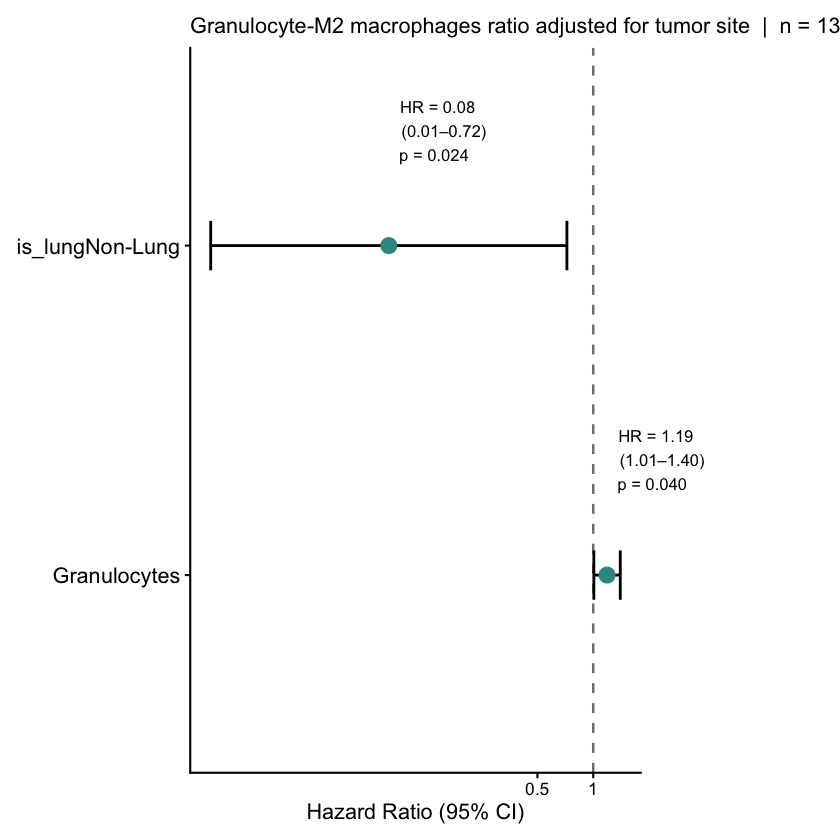

In [127]:
library(broom)
# Ratio effect adjusted for tumor site

cox_model <- coxph(Surv(survival_time_months, event) ~ Granulocytes + is_lung, 
                   data = celltype_percentage_patient_survival_gran)
summary(cox_model)

# Tidy the Cox model output
cox_tidy <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(
    term = recode(term,
      "ratio"          = "Granulocytes-dominance-ratio",
      "is_lungLung"  = "Tumor site (Lung)"
    )
  )

# Forest plot
ggplot(cox_tidy, aes(x = estimate, y = term)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.7) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.15, linewidth = 0.8, color = "black") +
  geom_point(size = 4, color = "#35978F") +
  geom_text(aes(label = sprintf("HR = %.2f\n(%.2f–%.2f)\np = %.3f",
                                 estimate, conf.low, conf.high, p.value)),
            hjust = -0.15, vjust = 0.5, size = 3.5, color = "black", position = position_nudge(y = 0.35)) +
  scale_x_log10(
    breaks = c(0.5, 1, 2, 5, 10, 50, 250),
    labels = c("0.5", "1", "2", "5", "10", "50", "250")
  ) +
  labs(
    x = "Hazard Ratio (95% CI)",
    y = NULL,
    subtitle = "Granulocyte-M2 macrophages ratio adjusted for tumor site  |  n = 13, events = 12"
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.subtitle = element_text(color = "black"),
    axis.text.y   = element_text(size = 13),
    plot.margin   = margin(10, 120, 10, 10)  # right margin for HR labels
  ) +
  coord_cartesian(clip = "off")  # allow labels outside plot area

ggsave(paste0(results_dir, "/cox_forest_plot.pdf"), width = 7, height = 3.5)

# G - 2

In [ ]:
celltype_percentage_patient_survival_gvsm2

Call:
coxph(formula = Surv(survival_time_months, event) ~ clr + is_lung, 
    data = celltype_percentage_patient_survival)

  n= 233, number of events= 215 

                 coef exp(coef)  se(coef)      z Pr(>|z|)    
clr         -0.002109  0.997893  0.037836 -0.056    0.956    
is_lungLung  2.941124 18.937113  0.261086 11.265   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

            exp(coef) exp(-coef) lower .95 upper .95
clr            0.9979    1.00211    0.9266     1.075
is_lungLung   18.9371    0.05281   11.3521    31.590

Concordance= 0.747  (se = 0.015 )
Likelihood ratio test= 209.4  on 2 df,   p=<2e-16
Wald test            = 126.9  on 2 df,   p=<2e-16
Score (logrank) test = 200.9  on 2 df,   p=<2e-16


`height` was translated to `width`.
`height` was translated to `width`.
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '(0.93–1.07)' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for '(11.35–31.59)' in 'mbcsToSbcs': - substituted for – (U+2013)”


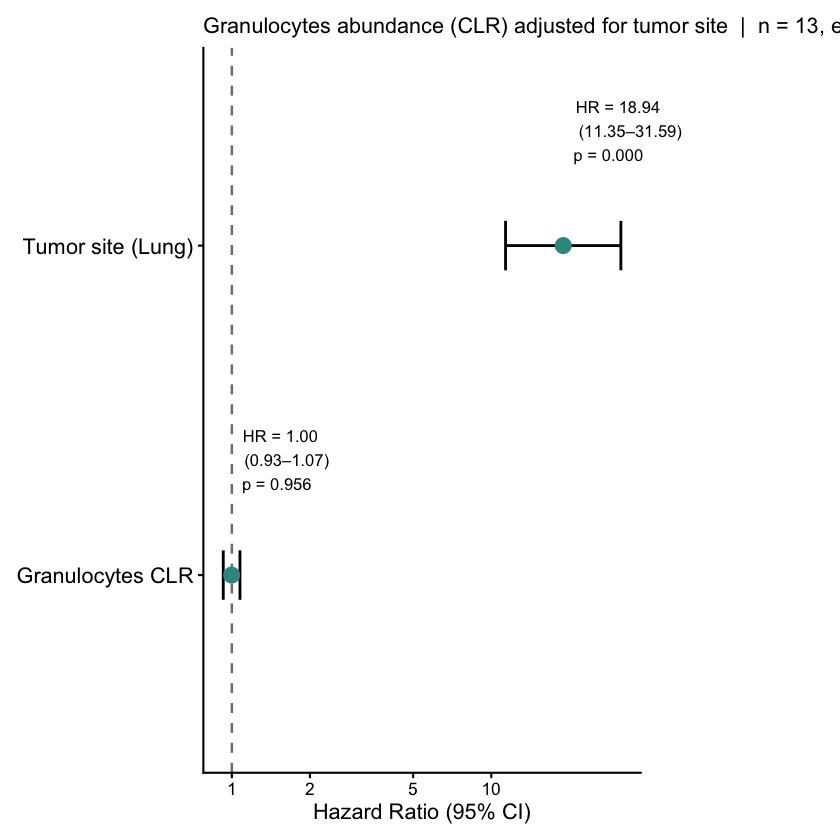

In [271]:
# Ratio effect adjusted for tumor site
cox_df <- celltype_percentage_patient_survival %>%
    filter(cell_category == "Granulocytes") %>%
    select(patient_ID, survival_time_months, event, clr, is_lung)

cox_model <- coxph(Surv(survival_time_months, event) ~ clr + is_lung, 
                   data = celltype_percentage_patient_survival)
summary(cox_model)

# Tidy the Cox model output
cox_tidy <- tidy(cox_model, exponentiate = TRUE, conf.int = TRUE) %>%
  mutate(
    term = recode(term,
      "clr"          = "Granulocytes CLR",
      "is_lungLung"  = "Tumor site (Lung)"
    )
  )

# Forest plot
ggplot(cox_tidy, aes(x = estimate, y = term)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.7) +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.15, linewidth = 0.8, color = "black") +
  geom_point(size = 4, color = "#35978F") +
  geom_text(aes(label = sprintf("HR = %.2f\n(%.2f–%.2f)\np = %.3f",
                                 estimate, conf.low, conf.high, p.value)),
            hjust = -0.15, vjust = 0.5, size = 3.5, color = "black", position = position_nudge(y = 0.35)) +
  scale_x_log10(
    breaks = c(0.5, 1, 2, 5, 10, 50, 250),
    labels = c("0.5", "1", "2", "5", "10", "50", "250")
  ) +
  labs(
    x = "Hazard Ratio (95% CI)",
    y = NULL,
    subtitle = "Granulocytes abundance (CLR) adjusted for tumor site  |  n = 13, events = 12"
  ) +
  theme_classic(base_size = 13) +
  theme(
    plot.subtitle = element_text(color = "black"),
    axis.text.y   = element_text(size = 13),
    plot.margin   = margin(10, 120, 10, 10)  # right margin for HR labels
  ) +
  coord_cartesian(clip = "off")  # allow labels outside plot area

ggsave(paste0(results_dir, "/cox_forest_plot.pdf"), width = 7, height = 3.5)

## EXPERIMENTING

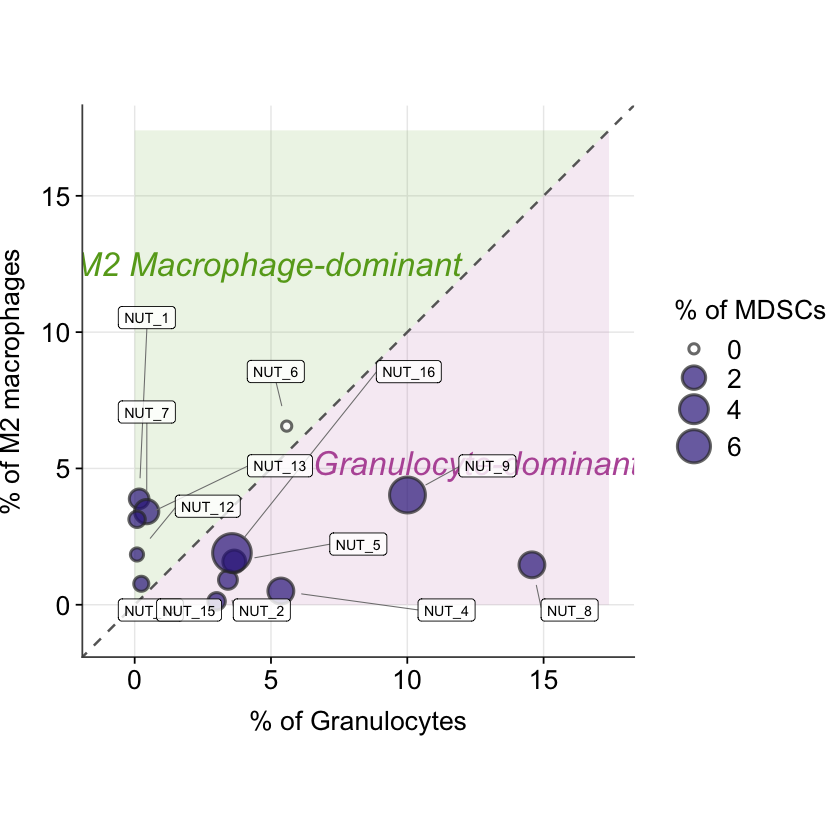

In [30]:
scatter_df <- celltype_percentage_patient_myeloid %>%
  filter(cell_category %in% c("Granulocytes", "M2 macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2 macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

ax_max <- max(scatter_df$granulocytes, scatter_df$m2_macro) * 1.2

ggplot(scatter_df, aes(x = granulocytes, y = m2_macro)) +

  # shaded triangles
  annotate("polygon",
           x = c(0, ax_max, ax_max),
           y = c(0, 0,      ax_max),
           fill = full_palette["Granulocytes"], alpha = 0.12) +
  annotate("polygon",
           x = c(0, 0,      ax_max),
           y = c(0, ax_max, ax_max),
           fill = full_palette["M2 macrophages"], alpha = 0.12) +

  # diagonal
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey40", linewidth = 0.7) +

  # region labels
  annotate("text",
           x = ax_max * 0.72, y = ax_max * 0.30,
           label = "Granulocyte-dominant",
           color = full_palette["Granulocytes"],
           size = 7, fontface = "italic") +
  annotate("text",
           x = ax_max * 0.28, y = ax_max * 0.72,
           label = "M2 Macrophage-dominant",
           color = full_palette["M2 macrophages"],
           size = 7, fontface = "italic") +

  # points
  geom_point(aes(size = mdscs,
                 fill = ifelse(mdscs == 0, "white", full_palette["MDSCs"])),
             shape    = 21,
             color    = "grey20",
             alpha    = 0.7,
             stroke   = 1.3,
             position = position_jitter(width = 0.15, height = 0.15, seed = 42)) +

  scale_fill_identity() +
  scale_size_continuous(
    name   = "% of MDSCs",
    range  = c(2, 10),
    breaks = c(0, 2, 4, 6)
  ) +

  guides(
    size = guide_legend(
      override.aes = list(
        fill  = c("white", full_palette["MDSCs"], full_palette["MDSCs"], full_palette["MDSCs"]),
        color = "grey20"
      )
    ),
    fill = "none"
  ) +

  # single geom_label_repel — no xlim/ylim constraints, just maximum repulsion
  geom_label_repel(
    aes(label = patient_ID),
    size               = 3,
    fill               = alpha("white", 0.80),
    label.size         = 0.2,
    box.padding        = 1.5,
    point.padding      = 0.8,
    max.overlaps       = Inf,
    force              = 15,
    force_pull         = 0.1,
    min.segment.length = 0,
    segment.color      = "grey50",
    segment.size       = 0.3,
    seed               = 42,
    position           = position_jitter(width = 0.15, height = 0.15, seed = 42)
  ) +

  coord_fixed(ratio = 1,
              xlim  = c(-1, ax_max),
              ylim  = c(-1, ax_max)) +

  labs(
    x = "% of Granulocytes",
    y = "% of M2 macrophages"
  ) +

  theme_classic(base_size = 16) +
  theme(
    legend.position  = "right",
    legend.title     = element_text(size = 16),
    legend.text      = element_text(size = 16),
    axis.text.x      = element_text(size = 16, colour = "black"),
    axis.title.x     = element_text(size = 16, colour = "black", margin = margin(t = 10)),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/granulocyte_m2_macro_scatter.pdf"),
       width = 10, height = 8, dpi = 300, bg = "white")

Granulocyte-dominant M2 Macrophage-dominant 
             "#B85AA6"              "#66A61E"

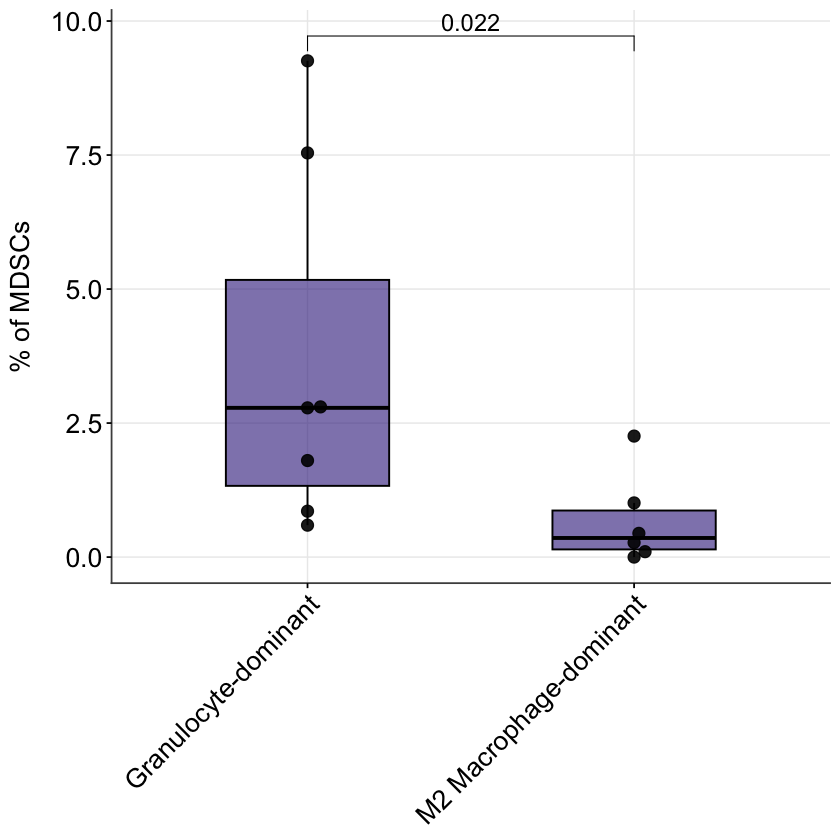

In [106]:
 scatter_df <- celltype_percentage_patient_myeloid %>%
  filter(cell_category %in% c("Granulocytes", "M2 macrophages", "MDSCs")) %>%
  select(patient_ID, cell_category, percentage) %>%
  pivot_wider(names_from = cell_category, values_from = percentage) %>%
  rename(
    granulocytes = Granulocytes,
    m2_macro     = `M2 macrophages`,
    mdscs        = MDSCs
  ) %>%
  mutate(
    mdscs    = replace_na(mdscs, 0),
    dominant = ifelse(granulocytes >= m2_macro, "gran", "m2")
  )

# Classify patients
mdsc_compare_df <- scatter_df %>%
  select(patient_ID, granulocytes, m2_macro, mdscs, dominant) %>%
  mutate(
    dominant_label = ifelse(dominant == "gran",
                            "Granulocyte-dominant",
                            "M2 Macrophage-dominant")
  )

comparisons <- list(c("Granulocyte-dominant", "M2 Macrophage-dominant"))

ggplot(mdsc_compare_df, aes(x = dominant_label, y = mdscs)) +

  geom_boxplot(
    width         = 0.5,
    alpha         = 0.6,
    fill          = full_palette["MDSCs"],
    color         = "black",
    outlier.shape = NA
  ) +

  geom_beeswarm(
    size  = 3,
    alpha = 0.9,
    color = "black",
    cex   = 2
  ) +

  stat_compare_means(
    comparisons = comparisons,
    method      = "wilcox.test",
    label       = "p.format",
    paired      = FALSE,
    size        = 5
  ) +

  labs(
    x = NULL,
    y = "% of MDSCs"
  ) +

  theme_classic(base_size = 12) +
  theme(
    legend.position  = "none",
    axis.text.x      = element_text(size = 16, colour = "black", angle = 45, hjust = 1),
    axis.text.y      = element_text(size = 16, colour = "black"),
    axis.title.y     = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line        = element_line(linewidth = 0.5, colour = "grey30"),
    axis.ticks       = element_line(linewidth = 0.5, colour = "black"),
    panel.grid.major = element_line(color = "grey92", linewidth = 0.4)
  )

ggsave(filename = paste0(results_dir, "/mdsc_gran_vs_m2_boxplot.pdf"),
       width = 6, height = 6, dpi = 300, bg = "white")

In [37]:
#niches enrichment and pvalues
enr_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment.csv"))
pvalue_df <- read_csv(file.path(data_dir, "neighborhood_cell_category_enrichment_pvalues.csv"))

Rows: 19 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (11): Epithelial_adjacent, Granulocytic_suppressive, Lymphatic_immune, L...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 19 Columns: 12
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): cell_category
dbl (11): Epithelial_adjacent, Granulocytic_suppressive, Lymphatic_immune, L...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
p_long <- pvalue_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "pvalue"
  )

enr_long <- enr_df %>%
  pivot_longer(
    cols = -cell_category,
    names_to = "neighborhood",
    values_to = "enrichment"
  )

df_plot <- enr_long %>%
  left_join(p_long, by = c("cell_category", "neighborhood")) %>%
  mutate(
    neighborhood = factor(neighborhood, levels = sort(unique(neighborhood))),
    cell_category = factor(cell_category)
  )

df_plot_filt <- df_plot %>%
  filter(enrichment > 0, pvalue < 0.01) %>%
  mutate(
    enrichment_cap = pmin(enrichment, 4),
    neglog10_p = -log10(pvalue)
  )

p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) + 
  scale_size_area(
    max_size = 7,
    breaks = c(1, 2, 3, 4),
    name = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
  low = "#fcbba1",
  high = "#99000d",
  name = expression(-log[10] * "(p-value)"),
  limits = c(2, 2.4),
  breaks = c(2.0, 2.2, 2.4)
) +
  labs(
    x = "Cell type",
    y = "Cellular neighborhood"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    text = element_text(colour = "black", size = 13),
    panel.grid.major = element_line(linewidth = 0.3),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 13, colour = "black"),
    axis.text.y = element_text(size = 13, colour = "black"),
    axis.title.y = element_text(size = 13, colour = "black", margin = margin(r = 10)),
    axis.title.x = element_text(size = 13, colour = "black", margin = margin(t = 1)),
    axis.line = element_line(color = "black")
  )

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot = p,
  width = 10,
  height = 6,
  device = cairo_pdf,
  dpi = 300,
  bg = "white"
)

In [35]:
cluster_palette <- c(

  "Tumor_bulk" = "#00B3A4",

  "Granulocytic_suppressive" = "#6A00F4",

  "Tumor_myeloid_enriched" = "#80ED99",

  "Lymphatic_immune" = "#1F78B4",

  "Vascular" = "#00BFC4",

  "Stromal_perivascular" = "#B39DDB",

  "Unknown_stromal" = "#6C757D",

  "Epithelial_adjacent" = "#C9B29B",

  "Unknown_tumor" = "#CED4DA",

  "TLS_like" = "#E76F51",

  "Lymphoid_T_enriched" = "#D62828"
)



In [42]:
# ── Niche color strip ─────────────────────────────────────────────────────────
niche_strip <- ggplot(
  data.frame(neighborhood = factor(levels(df_plot_filt$neighborhood),
                                   levels = levels(df_plot_filt$neighborhood))),
  aes(x = 1, y = neighborhood, fill = neighborhood)
) +
  geom_tile() +
  scale_fill_manual(values = cluster_palette) +
  scale_y_discrete(limits = rev) +
  labs(y = "Cellular neighborhood") +
  theme_void() +
  theme(
    legend.position = "none",
    axis.text.y     = element_text(size = 16, colour = "black", hjust = 0),
    axis.title.y    = element_text(size = 16, colour = "black", angle = 90, margin = margin(r = 10))
  )

# ── Main dot plot ─────────────────────────────────────────────────────────────
p <- ggplot(df_plot_filt, aes(x = cell_category, y = neighborhood)) +
  geom_point(
    aes(size = enrichment_cap, color = neglog10_p),
    alpha = 0.95
  ) +
  scale_y_discrete(limits = rev) +
  scale_size_area(
    max_size = 7,
    breaks   = c(1, 2, 3, 4),
    name     = expression("Log"[2] * " fold enrichment")
  ) +
  scale_color_gradient(
    low    = "#fcbba1",
    high   = "#99000d",
    name   = expression(-log[10] * "(p-value)"),
    limits = c(2, 2.4),
    breaks = c(2.0, 2.2, 2.4)
  ) +
  labs(
    x = "Cell type",
    y = NULL
  ) +
  theme_minimal(base_size = 13) +
    theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 16, colour = "black"),
    axis.title.x = element_blank(),
    axis.text.y = element_blank(),
    axis.title.y = element_text(size = 16, colour = "black", margin = margin(r = 10)),
    axis.line = element_line(linewidth = 0.5, colour = "black"),
    axis.ticks = element_line(linewidth = 0.5, colour = "black"),
  )

# ── Combine: strip on the left with names, dot plot on the right ──────────────
combined <- niche_strip + p +
  plot_layout(widths = c(0.05, 1))

ggsave(
  filename = file.path(results_dir, "enrichment_dotplot.pdf"),
  plot     = combined,
  width    = 12,
  height   = 6,
  device   = "pdf",
  dpi      = 300,
  bg       = "white"
)

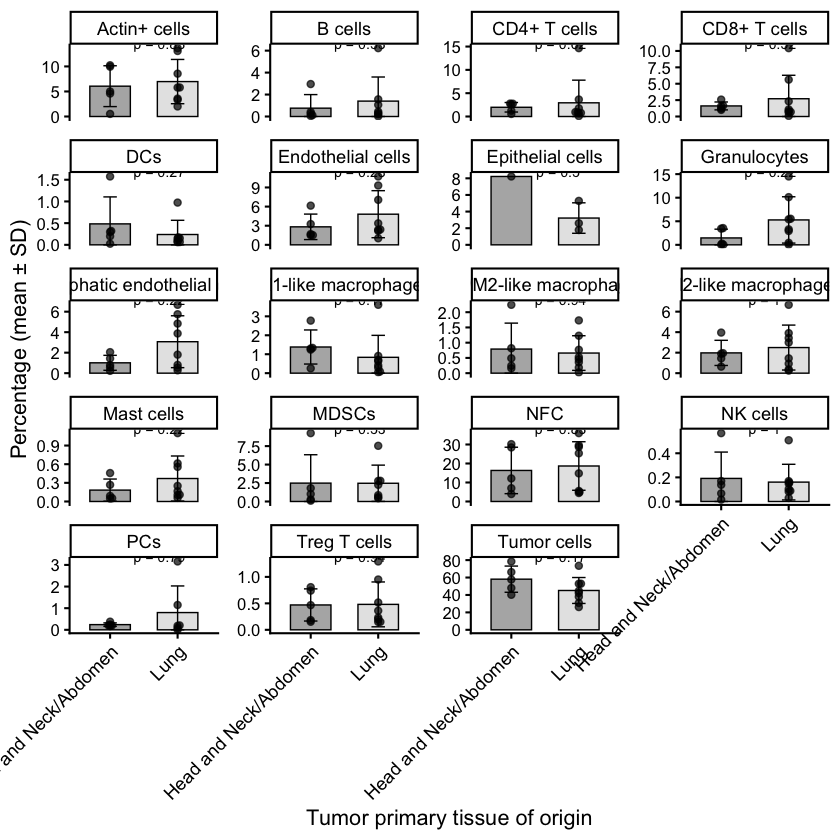

In [193]:
library(dplyr); library(tidyr); library(ggplot2); library(ggbeeswarm); library(ggpubr)

disp <- function(x) ifelse(x %in% names(rename_map), rename_map[x], x)

# tissue: Lung vs Head and Neck
site_lookup <- survival_df %>%
  distinct(patient_ID, is_lung) %>%
  mutate(is_lung = factor(is_lung, levels = c("Head and Neck/Abdomen", "Lung")))

plot_df <- celltype_percentage_patient %>%
  inner_join(site_lookup, by = "patient_ID") %>%
  mutate(cell_disp = disp(cell_category))

# mean + SD per tissue per cell type (bars)
bar_df <- plot_df %>%
  group_by(cell_disp, is_lung) %>%
  summarise(mean_pct = mean(percentage, na.rm = TRUE),
            sd_pct   = sd(percentage,   na.rm = TRUE), .groups = "drop")

p <- ggplot(plot_df, aes(x = is_lung, y = percentage)) +
  geom_col(data = bar_df, aes(y = mean_pct, fill = is_lung),
           width = 0.6, colour = "black", linewidth = 0.4) +
  geom_errorbar(data = bar_df,
                aes(y = mean_pct, ymin = pmax(mean_pct - sd_pct, 0),
                    ymax = mean_pct + sd_pct),
                width = 0.2, linewidth = 0.4, colour = "black") +
  geom_beeswarm(cex = 1.6, size = 1.6, alpha = 0.7, colour = "black") +
  stat_compare_means(method = "wilcox.test", label = "p.format",
                     label.x = 1.5, size = 3) +
  facet_wrap(~ cell_disp, scales = "free_y", ncol = 4) +
  scale_fill_manual(values = c("Head and Neck/Abdomen" = "grey70", "Lung" = "grey90"),
                    guide = "none") +
  labs(x = "Tumor primary tissue of origin", y = "Percentage (mean \u00b1 SD)") +
  theme_classic(base_family = "Arial", base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 11, colour = "black"),
        axis.text.y = element_text(size = 10, colour = "black"),
        strip.background = element_rect(fill = NA, colour = "black"),
        strip.text = element_text(size = 11, colour = "black"),
        panel.spacing = unit(0.8, "lines"))
p

ggsave(file.path(results_dir, "abundance_by_tissue_faceted_bar.pdf"),
       p, width = 14, height = 15, dpi = 300, bg = "white", device = cairo_pdf)

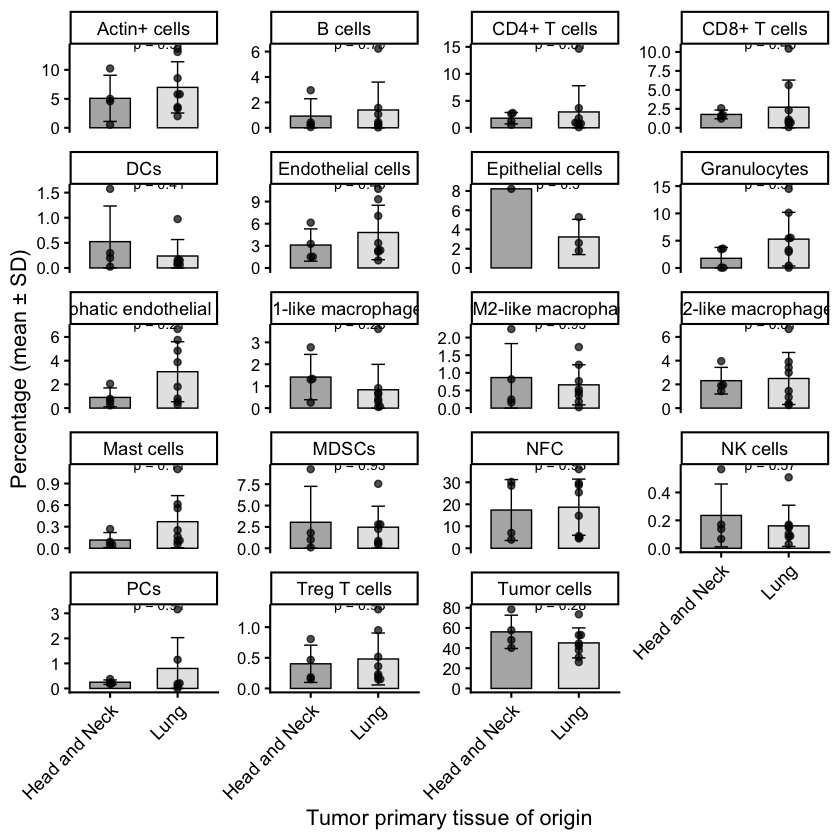

In [194]:
library(dplyr); library(tidyr); library(ggplot2); library(ggbeeswarm); library(ggpubr)

disp <- function(x) ifelse(x %in% names(rename_map), rename_map[x], x)

# tissue: keep only Lung and Head and Neck
site_lookup <- survival_df %>%
  distinct(patient_ID, tumor_site) %>%
  filter(tumor_site %in% c("Head and Neck", "Lung")) %>%
  mutate(tumor_site = factor(tumor_site, levels = c("Head and Neck", "Lung")))

plot_df <- celltype_percentage_patient %>%
  inner_join(site_lookup, by = "patient_ID") %>%
  mutate(cell_disp = disp(cell_category))

# mean + SD per tissue per cell type (bars)
bar_df <- plot_df %>%
  group_by(cell_disp, tumor_site) %>%
  summarise(mean_pct = mean(percentage, na.rm = TRUE),
            sd_pct   = sd(percentage,   na.rm = TRUE), .groups = "drop")

p <- ggplot(plot_df, aes(x = tumor_site, y = percentage)) +
  geom_col(data = bar_df, aes(y = mean_pct, fill = tumor_site),
           width = 0.6, colour = "black", linewidth = 0.4) +
  geom_errorbar(data = bar_df,
                aes(y = mean_pct, ymin = pmax(mean_pct - sd_pct, 0),
                    ymax = mean_pct + sd_pct),
                width = 0.2, linewidth = 0.4, colour = "black") +
  geom_beeswarm(cex = 1.6, size = 1.6, alpha = 0.7, colour = "black") +
  stat_compare_means(method = "wilcox.test", label = "p.format",
                     label.x = 1.5, size = 3) +
  facet_wrap(~ cell_disp, scales = "free_y", ncol = 4) +
  scale_fill_manual(values = c("Head and Neck" = "grey70", "Lung" = "grey90"),
                    guide = "none") +
  labs(x = "Tumor primary tissue of origin", y = "Percentage (mean \u00b1 SD)") +
  theme_classic(base_family = "Arial", base_size = 13) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1, size = 11, colour = "black"),
        axis.text.y = element_text(size = 10, colour = "black"),
        strip.background = element_rect(fill = NA, colour = "black"),
        strip.text = element_text(size = 11, colour = "black"),
        panel.spacing = unit(0.8, "lines"))
p

ggsave(file.path(results_dir, "abundance_by_tissue_faceted_bar.pdf"),
       p, width = 14, height = 15, dpi = 300, bg = "white", device = cairo_pdf)